<a href="https://colab.research.google.com/github/Lolalolytaaaa/ML-Diarciuc-Scotti-Casali-o-Caselli/blob/main/ML_Diarciuc%2C_Scotti%2C_Casali_o_Caselli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INTRODUZIONE**

***Progetto corso Laboratorio di ottimizzazione intelligenza artificiale e machine learning.***
Ana Maria Diarciuc, Laura Scotti, Chiara Casali o Caselli

1. **Introduzione del problema**: L'obiettivo del progetto è analizzare e modellare l'andamento temporale del volume di interesse degli utenti su Google in Italia negli ultimi 5 anni. Le abitudini digitali umane generano grandi quantità di dati che non seguono sempre una logica specifica: l'interesse verso una tematica può riproporsi ciclicamente, aumentare in modo imprevisto o crescere in modo costante. Il problema consiste nel capire se algoritmi matematici e di Machine Learning siano in grado di catturare queste dinamiche partendo dallo storico passato delle ricerche. Per ottenere esiti validi dall'analisi, abbiamo diviso il lavoro in tre scenari differenti:
1. **Ricerche a forte stagionalità ciclica** (Ana)
2. **Ricerche a trend lineare/esponenziale** (Laura)
3. **Ricerche volatili/evento-dipendenti** (Chiara)

Per ogni campo di ricerca implementeremo due modelli.

**Tipo di task:** Il lavoro nasce come un task di Time Series Forecasting (Previsione di serie temporali), che si colloca nell'ambito dell'Apprendimento Supervisionato (Regressione). Poiché l'ordine cronologico dei dati è un vincolo fondamentale, verrà usata una validazione di tipo temporale . Inoltre, nella gestione della serie volatile (evento-dipendente), il task richiederà una fase preliminare di Outlier Detection per isolare i picchi e comprendere come le anomalie influenzino le performance predittive.

**Obiettivo del progetto:** L'obiettivo del nostro progetto è implementare, addestrare e mettere a confronto due approcci diversi per ciascun campo di ricerca: un approccio statistico classico e un approccio basato sul Machine Learning supervisionato ad alberi di decisione. Il fine è verificare quale dei due è più efficiente nel prevedere il futuro nei tre scenari.

**Interesse pratico o applicativo del problema:** Saper prevedere i trend di ricerca su Google ha risvolti applicativi di fondamentale importanza nel mondo aziendale e della Business Intelligence: permette alle aziende di pianificare campagne pubblicitarie nei momenti esatti in cui l'interesse sta per salire, consente di intercettare in anticipo mercati o tecnologie emergenti e per i provider di servizi legati a grandi eventi mediatici, prevedere l'entità del picco permette di scalare l'infrastruttura dei server in anticipo, evitando crash di sistema.

# **1° CASO DI ANALISI**

* **Ricerche cicliche:** Tasse universitarie, ISEE, Regalare un libro
* **Domanda di business:** È possibile prevedere con anticipo i periodi di massimo interesse legati a scadenze fisse o festività? Saperlo permetterebbe di muoversi in anticipo, ad esempio ottimizzando le campagne marketing o gestendo meglio l'assistenza.
* **Cosa abbiamo fatto:** Abbiamo scaricato gli ultimi 5 anni di dati da Google Trends Italia (61 osservazioni mensili). Dopo aver convertito le date in variabili di calendario e aggiunto una feature di memoria storica (Lag-1), abbiamo messo a confronto una Regressione Lineare di base con un modello Gradient Boosting.

##### 2. **Descrizione del dataset**
Il dataset utilizzato nel progetto è stato estratto dalla piattaforma Google Trends Italia e copre 5 anni di ricerche, con una frequenza di campionamento delle osservazioni a cadenza periodica (settimanale/mensile).
La variabile quantitativa analizzata è l'Indice di Interesse nelle ricerche, un parametro sintetico espresso su una scala di misura normalizzata da 0 a 100, fornita direttamente dall'algoritmo di Google. All'interno di questa scala, il valore 100 segnala il momento di massimo picco assoluto e massima popolarità della parola chiave nel periodo e nel territorio considerati, mentre valori vicini allo 0 indicano un volume di ricerche assente o trascurabile.

Per lo svolgimento dell'analisi sono state selezionate tre distinte serie temporali, ciascuna rappresentativa di una casistica a forte stagionalità ciclica, legata a ricorrenze fisse su base annuale:
* **Tasse universitarie:** Ricerca legata alle scadenze del mondo accademico, con un picco di interesse concentrato tipicamente nei mesi autunnali.
* **ISEE:** Ricerca burocratica necessaria per le agevolazioni, con una fortissima impennata all'inizio dell'anno, in genere tra gennaio e febbraio.
* **Regalare un libro:** Ricerca legata alle festività e al mercato editoriale, con un picco molto netto e regolare che si verifica ogni anno nel mese di dicembre.

L'insieme di queste tre serie permette di valutare la capacità dei modelli predittivi nel gestire andamenti a onda, dove l'interesse cresce e cala seguendo un pattern stagionale che si ripete in modo regolare anno dopo anno.

##### 3. **Lettura e preparazione dei dati**

 In questa fase si acquisiscono e caricano i dati che verranno analizzati successivamente. Si scaricano i file .csv da Google Trends e ciascun dataset viene pre-elaborato per convertire i dati in formati comodi all'utilizzo. I tre file vengono uniti con un merge e viene condotta un'analisi di qualità per controllare l'integrità dei dati.

In [3]:
import pandas as pd

# caricamento dei vari csv
df_tasse = pd.read_csv('tasse_universitarie.csv', skiprows=1, names=['Data', 'tasse_universitarie'])
df_isee = pd.read_csv('isee.csv', skiprows=1, names=['Data', 'isee'])
df_libro = pd.read_csv('regalare_libro.csv', skiprows=1, names=['Data', 'regalare_libro'])

# conversione della colonna in formato temporale
df_tasse['Data'] = pd.to_datetime(df_tasse['Data'])
df_isee['Data'] = pd.to_datetime(df_isee['Data'])
df_libro['Data'] = pd.to_datetime(df_libro['Data'])

# unione dei dataframe
df_ana = df_tasse.merge(df_isee, on='Data')
df_ana = df_ana.merge(df_libro, on='Data')

# imposto la data
df_ana.set_index('Data', inplace=True)

# controllo della struttura dati
print("--- STRUTTURA DEL DATASET ---")
df_ana.info()

# controllo se vi sono dati vuoti
print("\n--- VALORI MANCANTI ---")
print(df_ana.isnull().sum())

# stampa delle prime 5 righe
print("\n--- ANTEPRIMA DATI ---")
print(df_ana.head())

--- STRUTTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2021-08-01 to 2026-08-01
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   tasse_universitarie  61 non-null     int64
 1   isee                 61 non-null     int64
 2   regalare_libro       61 non-null     int64
dtypes: int64(3)
memory usage: 1.9 KB

--- VALORI MANCANTI ---
tasse_universitarie    0
isee                   0
regalare_libro         0
dtype: int64

--- ANTEPRIMA DATI ---
            tasse_universitarie  isee  regalare_libro
Data                                                 
2021-08-01                   46    12              14
2021-09-01                   94    22              19
2021-10-01                   62    18              14
2021-11-01                   43    18              27
2021-12-01                   32    15              67


4. **Visualizzazione ed EDA**

In questa fase esploriamo visivamente i dati per evidenziare l'andamento delle ricerche online. Dai grafici emerge chiaramente la forte ciclicità legata a specifici periodi dell'anno:

- **Tasse universitarie:** picco autunnale (scadenze accademiche)
- **ISEE:** picco a inizio anno (gennaio/febbraio)
- **Regalare un libro:** picco a dicembre (festività natalizie)

Tramite la matrice di correlazione verifichiamo l'indipendenza statistica tra le tre serie storiche, a dimostrazione che l'interesse del pubblico verso questi temi segue cadenze stagionali ben distinte.


--- STATISTICHE DESCRITTIVE ---
       tasse_universitarie        isee  regalare_libro
count            61.000000   61.000000       61.000000
mean             50.868852   27.229508       27.147541
std              16.381367   20.212532       18.428995
min              29.000000   12.000000       12.000000
25%              40.000000   17.000000       18.000000
50%              46.000000   18.000000       21.000000
75%              54.000000   29.000000       28.000000
max             100.000000  100.000000      100.000000


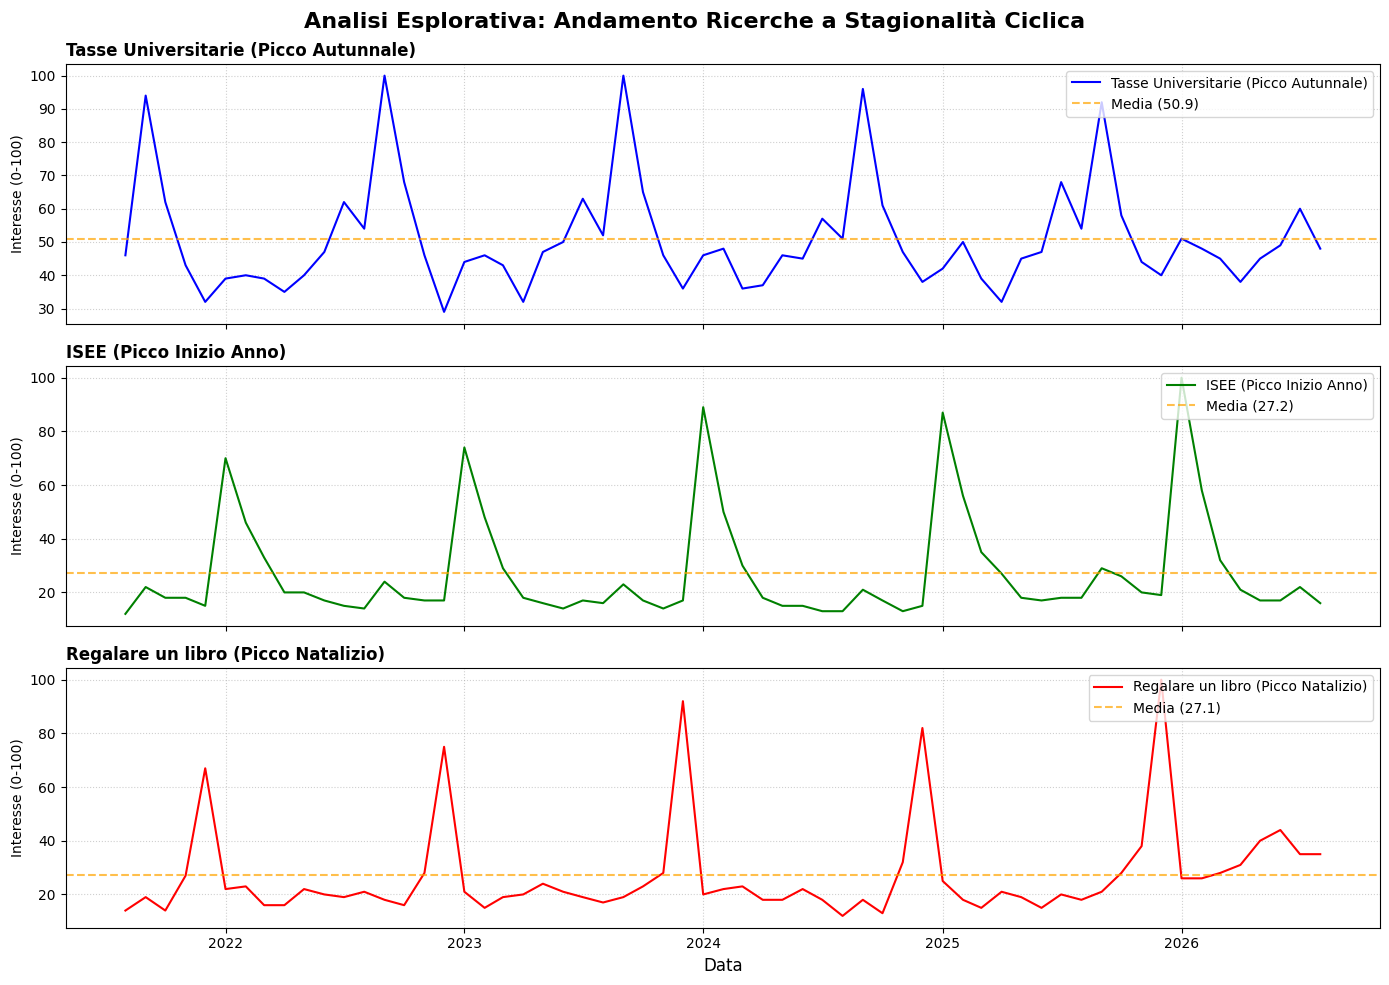

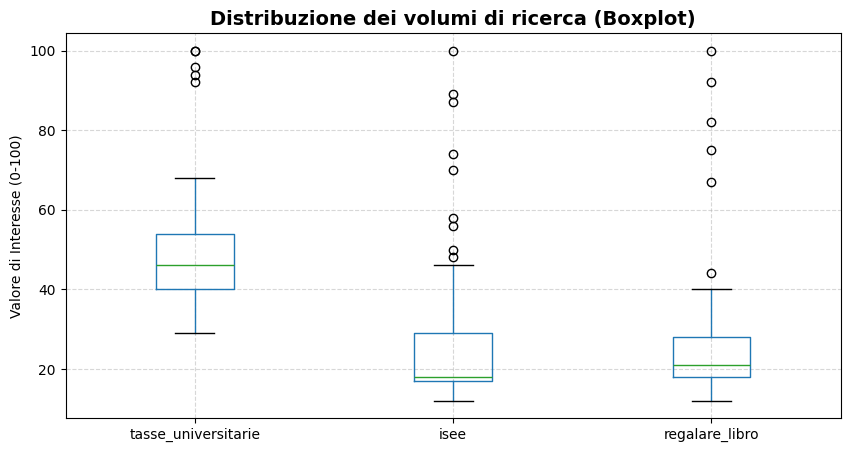

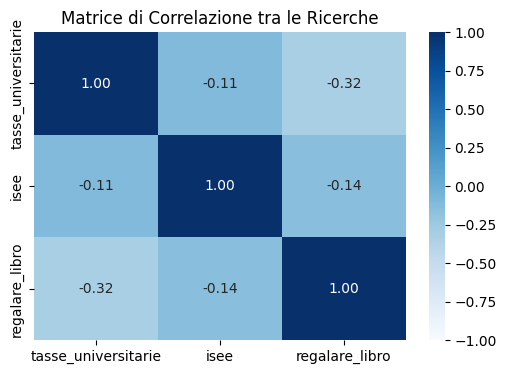

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# statistiche descrittive
print("\n--- STATISTICHE DESCRITTIVE ---")
print(df_ana.describe())

# griglia per i tre grafici
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

eventi_ana = [
    ('tasse_universitarie', 'blue', 'Tasse Universitarie (Picco Autunnale)'),
    ('isee', 'green', 'ISEE (Picco Inizio Anno)'),
    ('regalare_libro', 'red', 'Regalare un libro (Picco Natalizio)')
]

for ax, (colonna, colore, titolo) in zip(axes, eventi_ana):
    ax.plot(df_ana.index, df_ana[colonna], label=titolo, color=colore, linewidth=1.5)

    media = df_ana[colonna].mean()
    ax.axhline(media, color='orange', linestyle='--', alpha=0.7, label=f'Media ({media:.1f})')

    ax.set_title(titolo, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Interesse (0-100)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Data', fontsize=12)
fig.suptitle('Analisi Esplorativa: Andamento Ricerche a Stagionalità Ciclica', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# costruzione del boxplot
plt.figure(figsize=(10, 5))
df_ana.boxplot(column=['tasse_universitarie', 'isee', 'regalare_libro'])
plt.title('Distribuzione dei volumi di ricerca (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('Valore di Interesse (0-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Matrice di correlazione
plt.figure(figsize=(6, 4))
sns.heatmap(df_ana.corr(), annot=True, cmap='Blues', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matrice di Correlazione tra le Ricerche')
plt.show()

##### 5. **Feature Engineering e Preprocessing**

Trasformazione dei dati grezzi in un formato idoneo per l'addestramento dei modelli predittivi. A differenza delle serie volatili, per i nostri trend ciclici non andiamo a rimuovere i picchi, ma ci concentriamo sull'estrazione delle variabili di calendario e sulla creazione della memoria storica (Lag-1) per aiutare il modello a riconoscere i pattern ripetitivi.

In [5]:
import pandas as pd

df_prep = df_ana.copy()

# estrazione del mese e della settimana dall'indice temporale
df_prep['Mese'] = df_prep.index.month
df_prep['Settimana'] = df_prep.index.isocalendar().week.astype(int)

# creo il lag-1, ovvero la memoria storica
for col in ['tasse_universitarie', 'isee', 'regalare_libro']:
    df_prep[f'{col}_lag1'] = df_prep[col].shift(1)

df_prep.dropna(inplace=True)

# split temporale, con la divisione dal train al test
data_cerniera = '2025-06-01'

train = df_prep[df_prep.index < pd.to_datetime(data_cerniera)]
test = df_prep[df_prep.index >= pd.to_datetime(data_cerniera)]

print(f"Dataset di Training (Allenamento): {train.shape[0]} righe")
print(f"Dataset di Testing (Verifica): {test.shape[0]} righe")

Dataset di Training (Allenamento): 45 righe
Dataset di Testing (Verifica): 15 righe


##### 6. **Scelta e implementazione modelli**
In questa fase verranno addestrati due modelli differenti:

*   **Regressione Lineare:** È il modello supervisionato di riferimento, semplice e interpretabile. Viene utilizzata una combinazione lineare dele feature precedentemente usate (mese, settimana e Lag)in modo da poter stimare il valore del target. Serve da baseline per valutare se algoritmi più complessi portano un reale vantaggio sulle serie temporali.
*   **Gradient Boosting Trees (GBT):** È un modello avanzato di Machine Learning basato su un insieme di alberi di decisione. A differenza della Random Forest che costruisce alberi in modo indipendente, i Gradient Boosting Trees vengono costruiti in sequenza, dove ogni nuovo albero impara a correggere gli errori del precedente. Usa le colonne preparate prima per riconoscere i pattern complessi e catturare perfettamente le onde di stagionalità.

6.1. **Impostazione dell'addestramento multi-casistica:** Utilizzando il dataset unificato e preelaborato, si definisce la struttura di codice per applicare l'addestramento dei modelli su ciascuna delle tre casistiche. Per ogni evento, le feature definite in precedenza vengono passate alle matrici di Training (dati passati) e Test (dati futuri) rispettando il rigoroso ordine cronologico.

In [6]:
import pandas as pd

# preparazione delle feature temporali
df_prep['Mese'] = df_prep.index.month
df_prep['Settimana'] = df_prep.index.isocalendar().week.astype(int)

# feature di memoria storica
for col in ['tasse_universitarie', 'isee', 'regalare_libro']:
    df_prep[f'{col}_lag1'] = df_prep[col].shift(1)

# rimuovo le righe vuote
df_prep = df_prep.dropna()

# Split temporale
train_data = df_prep[df_prep.index < pd.to_datetime('2025-06-01')]
test_data = df_prep[df_prep.index >= pd.to_datetime('2025-06-01')]

dataset_casistiche = {}

for item in eventi_ana:
    # organizzazione dei dizionari di matrici
    target = item[0] if isinstance(item, tuple) else item
    features = ['Mese', 'Settimana', f'{target}_lag1']

    dataset_casistiche[target] = {
        'X_train': train_data[features],
        'y_train': train_data[target],
        'X_test': test_data[features],
        'y_test': test_data[target],
        'features': features
    }

print("--- Impostazione Dataset completata per le 3 casistiche ---")
for item in eventi_ana:
    target = item[0] if isinstance(item, tuple) else item
    print(f"Casistica '{target}': Train = {dataset_casistiche[target]['X_train'].shape[0]} righe, Test = {dataset_casistiche[target]['X_test'].shape[0]} righe")

--- Impostazione Dataset completata per le 3 casistiche ---
Casistica 'tasse_universitarie': Train = 44 righe, Test = 15 righe
Casistica 'isee': Train = 44 righe, Test = 15 righe
Casistica 'regalare_libro': Train = 44 righe, Test = 15 righe


6.2. **Implementazione del modello di Baseline: Regressione Lineare**

Come primo approccio si implementa la Regressione Lineare, che funge da modello di riferimento (baseline). Poiché la regressione lineare può estrapolare valori negativi (fisicamente inammissibili per l'indice di Google Trends che è compreso tra 0 e 100), si applica una correzione tramite la funzione `np.clip` per azzerare le stime inferiori allo zero.

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #funzioni che calcolano i parametri

# dizionari per memorizzare: i modelli lineari, le predizioni e i coefficienti
modelli_lr = {}
previsioni_lr = {}
coefficienti_lr = {}

print("--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---\n")

for item in eventi_ana:
    target = item[0] if isinstance(item, tuple) else item

    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # addestramento modello
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)

    # predizione dei valori negativi
    pred_lr = model_lr.predict(X_test)
    pred_lr = np.clip(pred_lr, 0, None)


    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # salvataggio nei dizionari
    modelli_lr[target] = model_lr
    previsioni_lr[target] = pred_lr
    coefficienti_lr[target] = model_lr.coef_

    # viene effettuata una stampa a video dei risultati per ciascun evento
    print(f"Casistica: {target.upper()}")
    print(f"  - Intercetta (Bias): {model_lr.intercept_:.2f}")
    print("  - Coefficienti (Pesi feature):")
    for feat, coef in zip(X_train.columns, model_lr.coef_):
        print(f"      {feat}: {coef:.2f}")
    print(f"  - Performance sul Test Set -> MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")
    print("-" * 50)

--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---

Casistica: TASSE_UNIVERSITARIE
  - Intercetta (Bias): 30.72
  - Coefficienti (Pesi feature):
      Mese: 0.32
      Settimana: 0.01
      tasse_universitarie_lag1: 0.33
  - Performance sul Test Set -> MAE: 8.19 | RMSE: 12.95 | R²: 0.0033
--------------------------------------------------
Casistica: ISEE
  - Intercetta (Bias): 45.69
  - Coefficienti (Pesi feature):
      Mese: -5.67
      Settimana: 0.60
      isee_lag1: 0.08
  - Performance sul Test Set -> MAE: 11.79 | RMSE: 17.43 | R²: 0.3523
--------------------------------------------------
Casistica: REGALARE_LIBRO
  - Intercetta (Bias): -5.96
  - Coefficienti (Pesi feature):
      Mese: 3.70
      Settimana: -0.11
      regalare_libro_lag1: 0.41
  - Performance sul Test Set -> MAE: 11.72 | RMSE: 16.54 | R²: 0.2799
--------------------------------------------------


6.3 **Modello Avanzato: Gradient Boosting Trees (GBT)**

Per migliorare le performance rispetto alla regressione lineare, utilizziamo un modello basato su alberi decisionali in sequenza. Anche in questo caso non ci affidiamo a configurazioni casuali, ma usiamo la tecnica del `GridSearchCV` per fare una ricerca automatica dei parametri migliori. Nello specifico, testiamo diverse combinazioni per il numero di alberi e per la loro profondità. Tramite la validazione incrociata, il sistema individua la combinazione ottimale per ciascuna serie storica, così da catturare al meglio l'andamento ciclico delle ricerche.

In [8]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

eventi_puliti = [item[0] if isinstance(item, tuple) else item for item in eventi_ana]

# griglia di ricerca per il GBT
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

# Dizionari per memorizzare i modelli ottimizzati
modelli_gbt_ottimizzati = {}
previsioni_gbt = {}
parametri_ottimali_gbt = {}
metriche_gbt = {}

print("--- OTTIMIZZAZIONE E ADDESTRAMENTO GRADIENT BOOSTING TREES ---\n")

for target in eventi_puliti:
    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']


    gbt_base = GradientBoostingRegressor(random_state=42)

    # inizializzazione della cross-validation
    tscv = TimeSeriesSplit(n_splits=5)

    # configurazione di GridSearchCV
    grid_search = GridSearchCV(
        estimator=gbt_base,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=1
    )

    # esecuzione train set
    grid_search.fit(X_train, y_train)

    # estrazione del modello migliore e generazione delle previsioni sul Test Set
    best_model = grid_search.best_estimator_
    pred_gbt = best_model.predict(X_test)
    pred_gbt = np.clip(pred_gbt, 0, None) # Clipping per evitare valori negativi

    # calcolo delle metriche di performance
    mae_gbt = mean_absolute_error(y_test, pred_gbt)
    rmse_gbt = np.sqrt(mean_squared_error(y_test, pred_gbt))
    r2_gbt = r2_score(y_test, pred_gbt)

    # salvataggio nei dizionari
    modelli_gbt_ottimizzati[target] = best_model
    parametri_ottimali_gbt[target] = grid_search.best_params_
    previsioni_gbt[target] = pred_gbt
    metriche_gbt[target] = {'MAE': mae_gbt, 'RMSE': rmse_gbt, 'R2': r2_gbt}

    # stampa a video dei risultati dettagliati
    print(f"Casistica: {target.upper()}")
    print(f"  - Migliori iperparametri trovati: {grid_search.best_params_}")
    print(f"  - Performance sul Test Set -> MAE: {mae_gbt:.2f} | RMSE: {rmse_gbt:.2f} | R2: {r2_gbt:.4f}")
    print("-" * 65)

--- OTTIMIZZAZIONE E ADDESTRAMENTO GRADIENT BOOSTING TREES ---

Casistica: TASSE_UNIVERSITARIE
  - Migliori iperparametri trovati: {'max_depth': 5, 'n_estimators': 50}
  - Performance sul Test Set -> MAE: 7.06 | RMSE: 12.57 | R2: 0.0617
-----------------------------------------------------------------
Casistica: ISEE
  - Migliori iperparametri trovati: {'max_depth': 3, 'n_estimators': 100}
  - Performance sul Test Set -> MAE: 3.91 | RMSE: 5.12 | R2: 0.9441
-----------------------------------------------------------------
Casistica: REGALARE_LIBRO
  - Migliori iperparametri trovati: {'max_depth': 3, 'n_estimators': 50}
  - Performance sul Test Set -> MAE: 10.45 | RMSE: 12.07 | R2: 0.6166
-----------------------------------------------------------------


6.4 **Estrazione e organizzazione delle previsioni**

 Mantenendo l'indice temporale originale dell'ultimo anno di osservazioni, le stime prodotte dalla Regressione Lineare e dal Gradient Boosting Trees vengono affiancate ai valori reali di ricerca. Questa fase conclude l'implementazione tecnica dei modelli, organizzando i risultati in un formato pronto per la successiva fase di confronto visivo e calcolo delle metriche.

In [9]:
import pandas as pd

risultati_previsioni = {}
eventi_puliti = list(dataset_casistiche.keys())

for target in eventi_puliti:
    # df per confrontare i due modelli con i dati reali
    df_pred = pd.DataFrame({
        'Valore_Reale': dataset_casistiche[target]['y_test'],
        'Pred_Reg_Lineare': previsioni_lr[target],
        'Pred_Gradient_Boosting': previsioni_gbt[target],
    }, index=dataset_casistiche[target]['X_test'].index)


    risultati_previsioni[target] = df_pred

# primi risultati
print("--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---\n")
for target in eventi_puliti:
    print(f"Casistica: {target.upper()} (Prime 5 osservazioni)")
    print(risultati_previsioni[target].head(5))
    print("-" * 60)

--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---

Casistica: TASSE_UNIVERSITARIE (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Gradient_Boosting
Data                                                              
2025-06-01            47         47.477144               46.666899
2025-07-01            68         48.479743               59.729377
2025-08-01            54         55.689970               52.484014
2025-09-01            92         51.459829               99.730797
2025-10-01            58         64.229842               61.381237
------------------------------------------------------------
Casistica: ISEE (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Gradient_Boosting
Data                                                              
2025-06-01            17         26.257822               15.472439
2025-07-01            18         23.513366               15.197862
2025-08-01            18         20.320978               15.

7. **Valutazione e controllo dei risultati**

In questa fase mettiamo a confronto l'accuratezza dei due modelli per capire quale dei due si comporta meglio. Tramite le metriche di errore calcolate sul set di test, verifichiamo se il nostro modello avanzato a Gradient Boosting Trees è riuscito a superare la regressione lineare di riferimento nel catturare i trend delle ricerche.

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# calcolo delle metriche standard
def calcola_metriche(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

risultati_metriche = {}

for target in dataset_casistiche.keys():
    # recupero dati reali del test set
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # Regressione Lineare
    pred_lr = modelli_lr[target].predict(X_test)
    pred_lr = np.clip(pred_lr, 0, None)
    met_lr = calcola_metriche(y_test, pred_lr)

    # Gradient Boosting Trees
    pred_gbt = modelli_gbt_ottimizzati[target].predict(X_test)
    pred_gbt = np.clip(pred_gbt, 0, None)
    met_gbt = calcola_metriche(y_test, pred_gbt)

    # salvataggio nel dizionario dei risultati
    risultati_metriche[f'{target} - LinReg'] = met_lr
    risultati_metriche[f'{target} - GBT'] = met_gbt

df_risultati_finali = pd.DataFrame.from_dict(risultati_metriche, orient='index')

print("-- TABELLA COMPARATIVA PERFORMANCE MODELLI --\n")
print(df_risultati_finali)

-- TABELLA COMPARATIVA PERFORMANCE MODELLI --

                                    MAE       RMSE        R2
tasse_universitarie - LinReg   8.193384  12.954929  0.003279
tasse_universitarie - GBT      7.064544  12.569354  0.061726
isee - LinReg                 11.790982  17.429217  0.352317
isee - GBT                     3.910376   5.122315  0.944058
regalare_libro - LinReg       11.724517  16.541552  0.279855
regalare_libro - GBT          10.451104  12.069634  0.616597


8. **Conclusioni finali**

 Il Gradient Boosting Trees (GBT) risulta nettamente migliore rispetto alla Regressione Lineare, come si può osservare dalle metriche studiate che analizzano l'errore tra il valore reale e quello previsto.

*   **MAE (Mean Absolute Error):** misura l'errore medio in valore assoluto; più è basso, più il valore è preciso.
*   **RMSE (Root Mean Squared Error):** misura dando più peso agli errori più grandi; anche in questo caso, più è basso, meglio è.
*   **R² (Coefficiente di Determinazione):** indica quanta variabilità dei dati il modello riesce a spiegare; più il valore è vicino a 1, più il modello è eccellente.

Osservando i valori, il Gradient Boosting Trees risulta superiore. La Regressione Lineare fallisce perché è vincolata da un'assunzione di linearità e non riesce a gestire correttamente i picchi stagionali e le curve improvvise delle ricerche. Al contrario, il GBT, grazie alla sua natura basata su alberi decisionali in sequenza, riesce ad adattarsi molto meglio ai pattern non lineari e a prevedere con precisione l'andamento delle nostre onde stagionali.

# **2° CASO DI ANALISI**

**Eventi mediatici:** Sanremo, Coppa Italia, Oscar

**Domanda di business:** Riusciamo a prevedere con anticipo i picchi di ricerca su Google per eventi mediatici e culturali per ottimizzare le campagne di Digital Marketing?

**Cosa abbiamo fatto:** Abbiamo analizzato 5 anni di storico di Google Trends Italia (261 osservazioni settimanali). Abbiamo trasformato le date in variabili di calendario e di memoria storica (Lag-1), confrontando un modello lineare base con un modello Random Forest.  

2. **Descrizione del dataset:** Il dataset utilizzato nel progetto è stato estratto dalla piattaforma Google Trends Italia e copre 5 anni di ricerche, con una frequenza di campionamento delle osservazioni a cadenza periodica (settimanale/mensile).

La variabile quantitativa analizzata è l'Indice di Interesse nelle ricerche, un parametro sintetico espresso su una scala di misura normalizzata da 0 a 100, fornita direttamente dall'algoritmo di Google.

All'interno di questa scala, il valore 100 segnala il momento di massimo picco assoluto e massima popolarità della parola chiave nel periodo e nel territorio considerati, mentre valori vicini allo 0 indicano un volume di ricerche assente o trascurabile.

Per lo svolgimento dell'analisi sono state selezionate tre distinte serie temporali, ciascuna rappresentativa di una casistica di eventi ad alta volatilità e fortemente evento-dipendenti, caratterizzati da una cadenza fissa su base annuale:

        - Sanremo: Evento mediatico e musicale a frequenza annuale fissa, concentrato tipicamente nel mese di Febbraio.
        - Coppa Italia: Evento sportivo calcistico a cadenza annuale fissa, la cui fase finale si colloca nel mese di Maggio.
        - Oscar: Evento cinematografico internazionale a cadenza annuale fissa, con picco di interesse concentrato nel mese di Marzo.
L'insieme di queste tre serie permette di valutare la capacità dei modelli predittivi nel gestire fenomeni impulsivi, dove l'interesse degli utenti rimane piatto per la maggior parte dell'anno per poi esplodere improvvisamente in corrispondenza dell'evento.

3. **Lettura e preparazione dei dati**.
In questa fase si acquisiscono e caricano i dati che verranno analizzati successivamente.
Si scaricano i file .csv da Google Trends e ciascun dataset viene pre-elaborato per convertire i dati in formati comodi all'utilizzo.
I tre file vengono uniti con un merge e viene condotta un'analisi di qualità per controllare l'integrità dei dati.

In [ ]:
import pandas as pd

# Caricamento dati
df_sanremo = pd.read_csv('sanremo.csv', skiprows=1, names=['Data', 'Sanremo'])
df_coppa = pd.read_csv('coppaita.csv', skiprows=1, names=['Data', 'coppaita'])
df_oscar = pd.read_csv('oscar.csv', skiprows=1, names=['Data', 'oscar'])

# Conversione del formato della colonna data
df_sanremo['Data'] = pd.to_datetime(df_sanremo['Data'])
df_coppa['Data'] = pd.to_datetime(df_coppa['Data'])
df_oscar['Data'] = pd.to_datetime(df_oscar['Data'])

# Unione del dataset
df_chiara = df_sanremo.merge(df_coppa, on='Data')
df_chiara = df_chiara.merge(df_oscar, on='Data')

# Data impostata come indice della tabella
df_chiara.set_index('Data', inplace=True)

# Ispezione della struttura dati
print("--- STRUTTURA DEL DATASET ---")
df_chiara.info()

# Controllo integrità dati
print("\n--- VALORI MANCANTI ---")
print(df_chiara.isnull().sum())

# Mostra le prime 5 righe
print("\n--- ANTEPRIMA DATI ---")
print(df_chiara.head())

--- STRUTTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2021-06-01 to 2026-06-01
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sanremo   61 non-null     int64
 1   coppaita  61 non-null     int64
 2   oscar     61 non-null     int64
dtypes: int64(3)
memory usage: 1.9 KB

--- VALORI MANCANTI ---
Sanremo     0
coppaita    0
oscar       0
dtype: int64

--- ANTEPRIMA DATI ---
            Sanremo  coppaita  oscar
Data                                
2021-06-01        3         0     22
2021-07-01        3         0     20
2021-08-01        4         0     26
2021-09-01        3         0     24
2021-10-01        2         0     17


4. **Visualizzazione ed EDA:** In questa fase vengono sistemati e mostrati i dati in grafici che evidenziano l'andamento delle ricerche online e si può notare principalmente i picchi di ricerche durante i periodi in cui accade l'evento.

-Sanremo: febbraio

-Finale Coppa Italia: maggio

-Premio Oscar: marzo

Tramite la matrice di correlazione è stato possibile verificare l'indipendenza statistica tra le tre serie storiche.
Questo dimostra che l'interesse del pubblico verso questi eventi segue cadenze definite in base al periodo dell'anno.


--- STATISTICHE DESCRITTIVE ---
          Sanremo    coppaita       oscar
count   61.000000   61.000000   61.000000
mean    10.295082    6.262295   30.000000
std     21.115827   21.466953   16.250128
min      2.000000    0.000000   17.000000
25%      3.000000    0.000000   22.000000
50%      3.000000    0.000000   24.000000
75%      6.000000    0.000000   30.000000
max    100.000000  100.000000  100.000000


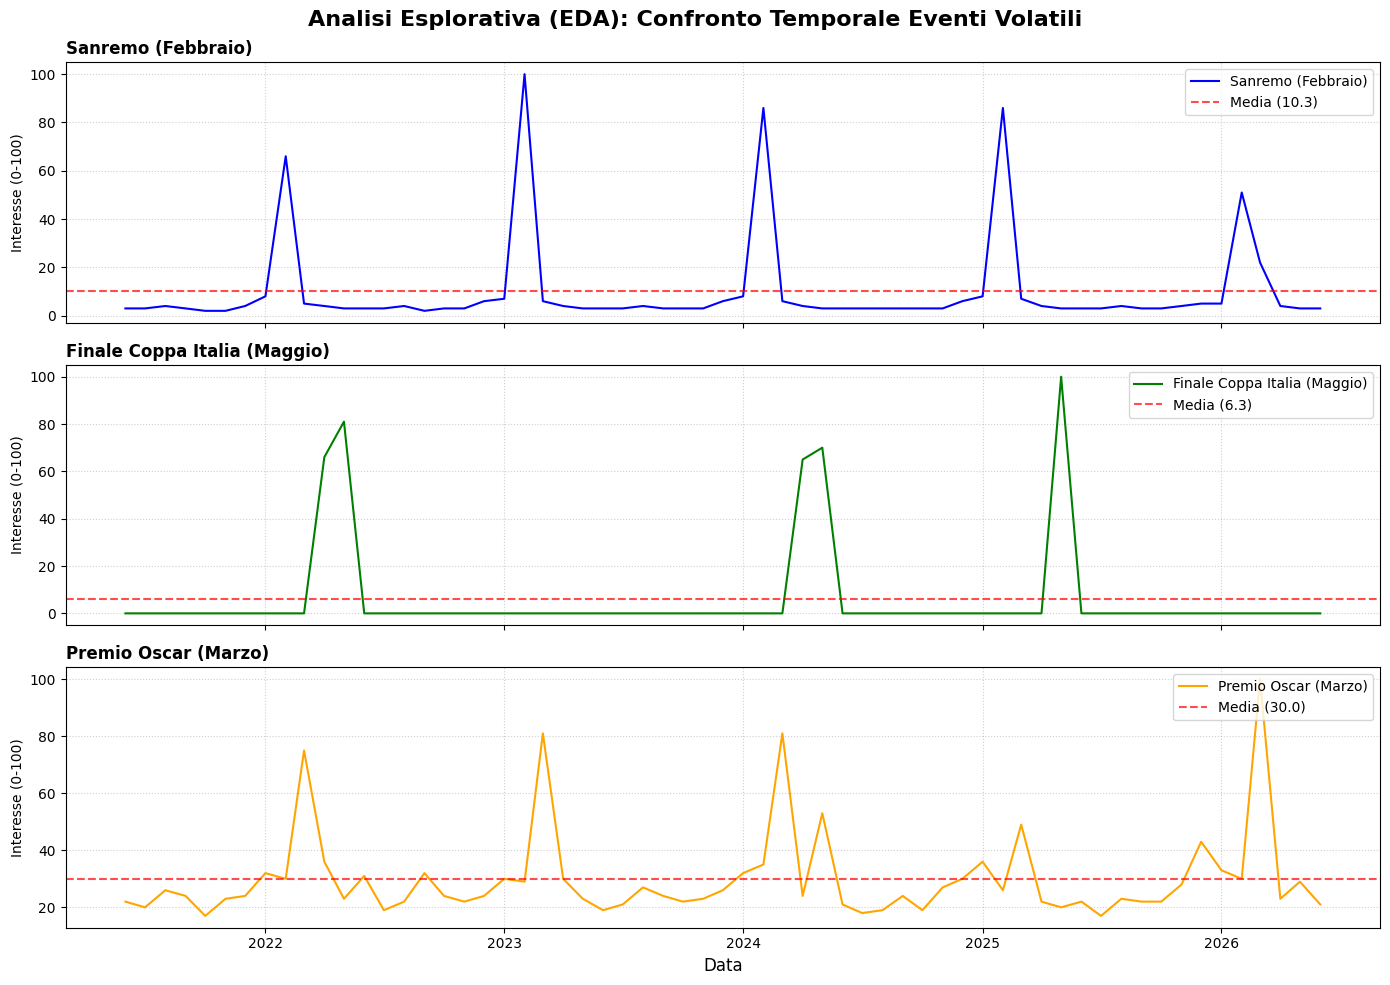

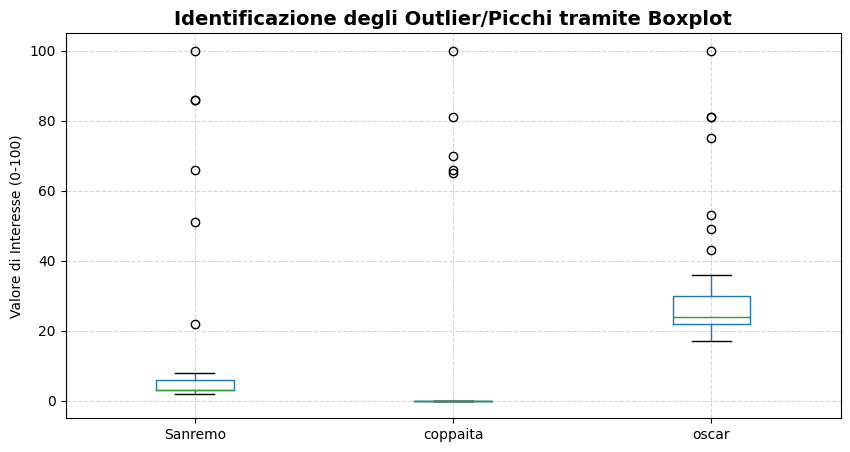

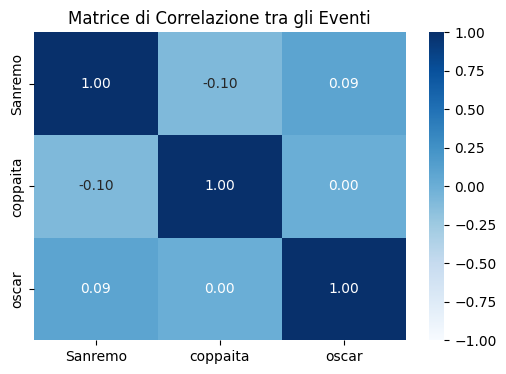

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- STATISTICHE DESCRITTIVE ---")
print(df_chiara.describe())

# Grafici
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True) #crea la griglia di sottografici

eventi = [
    ('Sanremo', 'blue', 'Sanremo (Febbraio)'),
    ('coppaita', 'green', 'Finale Coppa Italia (Maggio)'),
    ('oscar', 'orange', 'Premio Oscar (Marzo)')
]

for ax, (colonna, colore, titolo) in zip(axes, eventi):
    # Linea principale della serie temporale
    ax.plot(df_chiara.index, df_chiara[colonna], label=titolo, color=colore, linewidth=1.5)

    # Linea della media
    media = df_chiara[colonna].mean()
    ax.axhline(media, color='red', linestyle='--', alpha=0.7, label=f'Media ({media:.1f})')

    ax.set_title(titolo, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Interesse (0-100)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

# Impostazione dell'asse X comune
axes[-1].set_xlabel('Data', fontsize=12)
fig.suptitle('Analisi Esplorativa (EDA): Confronto Temporale Eventi Volatili', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


# Identificazione outilier
plt.figure(figsize=(10, 5))
df_chiara.boxplot(column=['Sanremo', 'coppaita', 'oscar'])

plt.title('Identificazione degli Outlier/Picchi tramite Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Valore di Interesse (0-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Matrice di Correlazione
plt.figure(figsize=(6, 4))
sns.heatmap(df_chiara.corr(), annot=True, cmap='Blues', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matrice di Correlazione tra gli Eventi')
plt.show()

5. **Outlier detection / preprocessing** trasformazione dei dati grezzi in un formato idoneo per l'addestramento dei modelli predittivi (trattamento degli outlier, nel punto 4 sono solo stati scoperti)

In [ ]:
import pandas as pd

df_prep = df_chiara.copy()

df_prep['Mese'] = df_prep.index.month
df_prep['Settimana'] = df_prep.index.isocalendar().week.astype(int)

for col in ['Sanremo', 'coppaita', 'oscar']:
    df_prep[f'{col}_lag1'] = df_prep[col].shift(1) #feature di memoria storica
df_prep.dropna(inplace=True)

#Split Temporale
data_cerniera = '2025-06-01'

train = df_prep[df_prep.index < pd.to_datetime(data_cerniera)]
test = df_prep[df_prep.index >= pd.to_datetime(data_cerniera)]

print(f"Dataset di Training: {train.shape[0]} righe")
print(f"Dataset di Testing: {test.shape[0]} righe")

Dataset di Training: 47 righe
Dataset di Testing: 13 righe


6. **Scelta e implementazione modelli:** In questa fase verranno addestrati due modelli differenti:

**Regressione lineare:** È il modello supervisionato di riferimento semplice e interpretabile. Utilizza una combinazione lineare delle feature preparate al Punto 5 (Mese, Settimana e Lag) per stimare il valore del target. Serve da baseline per valutare se algoritmi più complessi portano un reale vantaggio sulle serie temporali.

**Random Forest:** È il modello di Machine Learning basato su alberi di decisione. Usa le colonne che sono state preparate prima (Mese, Settimana e Lag) per imparare le regole e riconoscere quando sta per scattare il picco.

6.1. **Impostazione dell'addestramento multi-casistica:** Utilizzando il dataset unificato e preelaborato, si definisce la struttura di codice per applicare l'addestramento dei modelli su ciascuna delle tre casistiche. Per ogni evento, le feature definite in precedenza vengono passate alle matrici di Training (80%) e Test (20%) rispettando l'ordine cronologico.

In [ ]:
import pandas as pd

# Recupero e verifica del DataFrame
df_prep['Mese'] = df_prep.index.month
df_prep['Settimana'] = df_prep.index.isocalendar().week.astype(int)

# Feature di memoria storica
for col in ['Sanremo', 'coppaita', 'oscar']:
    df_prep[f'{col}_lag1'] = df_prep[col].shift(1)

# Rimozione delle righe vuote
df_prep = df_prep.dropna()

# Split temporale
train_data = df_prep[df_prep.index < pd.to_datetime('2025-06-01')]
test_data = df_prep[df_prep.index >= pd.to_datetime('2025-06-01')]

dataset_casistiche = {}

for item in eventi:
    # Organizzazione in dizionari di matrici
    target = item[0] if isinstance(item, tuple) else item
    features = ['Mese', 'Settimana', f'{target}_lag1']

    dataset_casistiche[target] = {
        'X_train': train_data[features],
        'y_train': train_data[target],
        'X_test': test_data[features],
        'y_test': test_data[target],
        'features': features
    }

print("--- Impostazione Dataset completata per le 3 casistiche ---")
for item in eventi:
    target = item[0] if isinstance(item, tuple) else item
    print(f"Casistica '{target}': Train = {dataset_casistiche[target]['X_train'].shape[0]} righe, Test = {dataset_casistiche[target]['X_test'].shape[0]} righe")

--- Impostazione Dataset completata per le 3 casistiche ---
Casistica 'Sanremo': Train = 46 righe, Test = 13 righe
Casistica 'coppaita': Train = 46 righe, Test = 13 righe
Casistica 'oscar': Train = 46 righe, Test = 13 righe


6.2. **Implementazione del modello di Baseline: Regressione Lineare**

Come primo approccio si implementa la Regressione Lineare, che funge da modello di riferimento (baseline). Poiché la regressione lineare può estrapolare valori negativi (fisicamente inammissibili per l'indice di Google Trends che è compreso tra 0 e 100), si applica una correzione tramite la funzione np.clip per azzerare le stime inferiori allo zero.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eventi_puliti = [item[0] if isinstance(item, tuple) else item for item in eventi]

# Definizione dizionari
modelli_lr = {}
previsioni_lr = {}
coefficienti_lr = {}

print("--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---\n")

for item in eventi:
    target = item[0] if isinstance(item, tuple) else item

    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # Addestramento del modello
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)

    # Predizione dei valori negativi
    pred_lr = model_lr.predict(X_test)
    pred_lr = np.clip(pred_lr, 0, None)

    # Calcolo delle metriche
    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # Salvataggio nei dizionari
    modelli_lr[target] = model_lr
    previsioni_lr[target] = pred_lr
    coefficienti_lr[target] = model_lr.coef_

    # Stampa a video dei risultati per ciascun evento
    print(f"Casistica: {target.upper()}")
    print(f"  - Intercetta (Bias): {model_lr.intercept_:.2f}")
    print(f"  - Coefficienti (Pesi feature):")
    for feat, coef in zip(X_train.columns, model_lr.coef_):
        print(f"      {feat}: {coef:.2f}")
    print(f"  - Performance sul Test Set -> MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")
    print("-" * 50)

--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---

Casistica: SANREMO
  - Intercetta (Bias): 37.82
  - Coefficienti (Pesi feature):
      Mese: -1.57
      Settimana: -0.52
      Sanremo_lag1: -0.24
  - Performance sul Test Set -> MAE: 10.65 | RMSE: 13.27 | R²: -0.0152
--------------------------------------------------
Casistica: COPPAITA
  - Intercetta (Bias): 14.12
  - Coefficienti (Pesi feature):
      Mese: -0.15
      Settimana: -0.27
      coppaita_lag1: 0.38
  - Performance sul Test Set -> MAE: 9.52 | RMSE: 14.74 | R²: 0.0000
--------------------------------------------------
Casistica: OSCAR
  - Intercetta (Bias): 48.26
  - Coefficienti (Pesi feature):
      Mese: -1.17
      Settimana: -0.25
      oscar_lag1: -0.13
  - Performance sul Test Set -> MAE: 12.79 | RMSE: 19.86 | R²: 0.0811
--------------------------------------------------


6.3 **Modello Avanzato: Random Forest:** il Random Forest Regressor non è stato sottoposto a una procedura di Hyperparameter Tuning tramite GridSearchCV.
Per ciascuna delle tre casistiche, viene eseguita una ricerca su una griglia di iperparametri per trovare la combinazione ottimale in grado di minimizzare l'errore predittivo: n_estimators (numero di alberi nella foresta: 50, 100 o 150), max_depth (profondità massima degli alberi: illimitata o bloccata a 5/10) e min_samples_split (campioni minimi per dividere un nodo: 2 o 5).
Attraverso una validazione incrociata l'algoritmo individua la configurazione migliore per ogni specifico evento, garantendo la configurazione migliore per ogni casistica.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eventi_puliti = [item[0] if isinstance(item, tuple) else item for item in eventi]

# Definizione della griglia di iperparametri da esplorare
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

# Dizionari per memorizzare i modelli
modelli_rf_ottimizzati = {}
previsioni_rf = {}
parametri_ottimali = {}
metriche_rf = {}

print("--- OTTIMIZZAZIONE E ADDESTRAMENTO RANDOM FOREST ---\n")

for target in eventi_puliti:
    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # Inizializzazione del Random Forest
    rf_base = RandomForestRegressor(random_state=42)

    # Configurazione di GridSearchCV
    grid_search = GridSearchCV(
        estimator=rf_base,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=1
)

    # Esecuzione dell'ottimizzazione sul Training Set
    grid_search.fit(X_train, y_train)

    # Estrazione del modello migliore e generazione delle previsioni sul Test Set
    best_model = grid_search.best_estimator_
    pred_rf = best_model.predict(X_test)

    # Calcolo delle metriche
    mae_rf = mean_absolute_error(y_test, pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
    r2_rf = r2_score(y_test, pred_rf)

    # Salvataggio nei dizionari
    modelli_rf_ottimizzati[target] = best_model
    parametri_ottimali[target] = grid_search.best_params_
    previsioni_rf[target] = pred_rf

    # Stampa a video dei risultati
    print(f"Casistica: {target.upper()}")
    print(f"  - Migliori iperparametri trovati: {grid_search.best_params_}")
    print(f"  - Performance sul Test Set -> MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")
    print("-" * 65)

--- OTTIMIZZAZIONE E ADDESTRAMENTO RANDOM FOREST ---

Casistica: SANREMO
  - Migliori iperparametri trovati: {'max_depth': None, 'n_estimators': 200}
  - Performance sul Test Set -> MAE: 3.61 | RMSE: 6.67 | R²: 0.7434
-----------------------------------------------------------------
Casistica: COPPAITA
  - Migliori iperparametri trovati: {'max_depth': None, 'n_estimators': 200}
  - Performance sul Test Set -> MAE: 7.09 | RMSE: 17.30 | R²: 0.0000
-----------------------------------------------------------------
Casistica: OSCAR
  - Migliori iperparametri trovati: {'max_depth': 10, 'n_estimators': 100}
  - Performance sul Test Set -> MAE: 5.85 | RMSE: 9.62 | R²: 0.7844
-----------------------------------------------------------------


6.4. **Estrazione e organizzazione delle previsioni:** Mantenendo l'indice temporale originale dell'ultimo anno di osservazioni, le stime prodotte dalla Regressione Lineare e dal Random Forest Regressor vengono affiancate ai valori reali di ricerca. Questa fase conclude l'implementazione tecnica dei modelli, organizzando gli output predittivi in un formato pronto per la successiva fase di valutazione quantitativa e calcolo delle metriche di performance.

In [ ]:
import pandas as pd


# Dizionario globale per raccogliere i risultati
risultati_previsioni = {}

eventi_puliti = list(dataset_casistiche.keys())

for target in eventi_puliti:
   # Creazione del DataFrame di confronto
   df_pred = pd.DataFrame({
       'Valore_Reale': dataset_casistiche[target]['y_test'],
       'Pred_Reg_Lineare': previsioni_lr[target],
       'Pred_Random_Forest': previsioni_rf[target],
   }, index=dataset_casistiche[target]['X_test'].index)

   # Salvataggio nel dizionario principale
   risultati_previsioni[target] = df_pred

# Visualizzazione delle prime 5 osservazioni per ogni evento
print("--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---")
for target in eventi_puliti:
   print(f"\n[Casistica: {target.upper()}] (Prime 5 osservazioni)")
   print(risultati_previsioni[target].head(5))


--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---

[Casistica: SANREMO] (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Random_Forest
Data                                                          
2025-06-01             3         16.154533            3.000000
2025-07-01             3         11.963360            3.013750
2025-08-01             4          8.297068            3.630042
2025-09-01             3          3.866278            2.702679
2025-10-01             3          0.439602            2.873250

[Casistica: COPPAITA] (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Random_Forest
Data                                                          
2025-06-01             0         45.526281               6.285
2025-07-01             0          5.753794               0.000
2025-08-01             0          4.520155               0.000
2025-09-01             0          3.015604               0.000
2025-10-01             0          1.781964

7. **Valutazione e controllo dei risultati:** valutazione dell'accuratezza dei due modelli e scelta del modello migliore

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Funzione riutilizzabile
def calcola_metriche(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

risultati_previsioni = {}

for target in dataset_casistiche.keys():
    # Recupero dati
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # Regressione lineare
    pred_lr = modelli_lr[target].predict(X_test)
    met_lr = calcola_metriche(y_test, pred_lr)

    # Random forest
    pred_rf = modelli_rf_ottimizzati[target].predict(X_test)
    met_rf = calcola_metriche(y_test, pred_rf)

    # Salvataggio nel dizionario dei risultati
    risultati_previsioni[f'{target} -LinReg'] = met_lr
    risultati_previsioni[f'{target} -RandFor'] = met_rf

# Trasformazione di DataFrame di Pandas
df_risulati_finali = pd.DataFrame.from_dict(risultati_previsioni, orient='index')

print("-- TABELLA COMPARATIVA PERFORMANCE MODELLI --")
print(df_risulati_finali)


-- TABELLA COMPARATIVA PERFORMANCE MODELLI --
                         MAE       RMSE        R2
Sanremo -LinReg    11.489281  13.757530 -0.091245
Sanremo -RandFor    3.612562   6.670679  0.743444
coppaita -LinReg    9.592218  14.739466  0.000000
coppaita -RandFor   7.094951  17.298453  0.000000
oscar -LinReg      12.785469  19.863637  0.081145
oscar -RandFor      5.848802   9.622461  0.784374


8. **Conclusioni finali:** Il Random Forest risulta migliore rispetto alla Regressione Lineare e lo si può osservare attraverso le metriche studiate che analizzano l'errore tra il valore reale e quello previsto.

**MAE** misura l'errore medio in in valore assoluto, più è basso più il valore è preciso.

**RMSE** misura dando peso agli errori più grandi, più è basso meglio è.

**R2** indica quanta variabilità dei dati il modello riesce a spiegare, più il valore è vicino a 1, più il modello è eccellente.

Quindi osservando i valori, il Random Forest risulta nettamente migliore.
La Regressione Lineare fallisce perchè è vincolata da un'assunzione di linearità, quindi fallisce nel prevedere i picchi annuali.
Al contrario Random Forest ha una natura non lineare basata su alberi decisionali e quindi riesce a prevedere con molta più precisione l'andamento dei trend.

# **3° CASO DI ANALISI**

**Eventi analizzati:** Intelligenza artificiale, Auto elettrica, Smart working

**Domanda di business:** Riusciamo a prevedere con anticipo la crescita costante o la stabilizzazione di interesse su Google per tecnologie e trend emergenti, in modo da riallocare strategicamente le risorse e gli investimenti?

**Cosa abbiamo fatto:** Abbiamo analizzato 5 anni di storico di Google Trends Italia (261 osservazioni settimanali). Abbiamo trasformato le date in variabili di calendario e di memoria storica (Lag-1), confrontando un modello lineare base con un modello Extra Trees Regressor.

2. **Descrizione del dataset:** Il dataset utilizzato nel progetto è stato estratto dalla piattaforma Google Trends Italia e copre 5 anni di ricerche, con una frequenza di campionamento delle osservazioni a cadenza periodica (settimanale/mensile).

La variabile quantitativa analizzata è l'Indice di Interesse nelle ricerche, un parametro sintetico espresso su una scala di misura normalizzata da 0 a 100, fornita direttamente dall'algoritmo di Google.

All'interno di questa scala, il valore 100 segnala il momento di massimo picco assoluto e massima popolarità della parola chiave nel periodo e nel territorio considerati, mentre valori vicini allo 0 indicano un volume di ricerche assente o trascurabile.

Per lo svolgimento dell'analisi sono state selezionate tre distinte serie temporali, ciascuna rappresentativa di una casistica di trend a crescita lineare, esponenziale o di stabilizzazione strutturale:

        - Intelligenza artificiale: Trend tecnologico caratterizzato da una fortissima crescita esponenziale e da volumi in ascesa, specialmente a partire dal 2023.
        - Auto elettrica: Trend legato alla transizione ecologica, caratterizzato da una crescita complessiva del volume di interesse nel tempo unita a una spiccata ciclicità.
        - Smart working: Trend legato a un cambiamento strutturale delle abitudini lavorative, caratterizzato da un'alta volatilità iniziale (post-pandemica) seguita da una successiva fase di stabilizzazione e assestamento.

L'insieme di queste tre serie permette di valutare la capacità dei modelli predittivi nel gestire sia trend in forte e continua espansione, sia dinamiche strutturali a lungo termine.

3. **Lettura e preparazione dei dati.** In questa fase si acquisiscono e caricano i dati che verranno analizzati successivamente. Si scaricano i file .csv da Google Trends e ciascun dataset viene pre-elaborato per convertire i dati in formati comodi all'utilizzo. I tre file vengono uniti con un merge e viene condotta un'analisi di qualità per controllare l'integrità dei dati.

In [ ]:
import pandas as pd

# caricamento csv
df_ia = pd.read_csv('intelligenza_artificiale.csv', skiprows=1, names=['Data', 'intelligenza_artificiale'])
df_auto = pd.read_csv('autoelettrica.csv', skiprows=1, names=['Data', 'autoelettrica'])
df_smart = pd.read_csv('smart_working.csv', skiprows=1, names=['Data', 'smart_working'])

# converto la colonna data in datetime
df_ia['Data'] = pd.to_datetime(df_ia['Data'])
df_auto['Data'] = pd.to_datetime(df_auto['Data'])
df_smart['Data'] = pd.to_datetime(df_smart['Data'])

# unione del dataset
df_laura = df_ia.merge(df_auto, on='Data')
df_laura = df_laura.merge(df_smart, on='Data')

# data impostata come indice
df_laura.set_index('Data', inplace=True)

# struttura dati
print("--- STRUTTURA DEL DATASET ---")
df_laura.info()

# controllo integrità dati
print("\n--- VALORI MANCANTI ---")
print(df_laura.isnull().sum())

# stampa anteprima di dati
print("\n--- ANTEPRIMA DATI ---")
print(df_laura.head())

--- STRUTTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2021-08-01 to 2026-08-01
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   intelligenza_artificiale  61 non-null     int64
 1   autoelettrica             61 non-null     int64
 2   smart_working             61 non-null     int64
dtypes: int64(3)
memory usage: 1.9 KB

--- VALORI MANCANTI ---
intelligenza_artificiale    0
autoelettrica               0
smart_working               0
dtype: int64

--- ANTEPRIMA DATI ---
            intelligenza_artificiale  autoelettrica  smart_working
Data                                                              
2021-08-01                         4              0             42
2021-09-01                         5              0             88
2021-10-01                        10              0             74
2021-11-01                         7              0       

4. **Visualizzazione ed EDA:** In questa fase vengono sistemati e mostrati i dati in grafici che evidenziano l'andamento delle ricerche online e si può notare come i trend si sono sviluppati nel corso del tempo.

*   **Intelligenza artificiale:** crescita esponenziale dal 2023.
*   **Auto elettrica:** trend in crescita nel lungo periodo unito a una forte ciclicità stagionale.
*   **Smart working:** picchi iniziali e successiva stabilizzazione.

Tramite la matrice di correlazione è stato possibile verificare le dipendenze statistiche tra le tre serie storiche. Questo ci permette di osservare se alcune tematiche sono cresciute in parallelo o in modo del tutto indipendente.


--- STATISTICHE DESCRITTIVE ---
       intelligenza_artificiale  autoelettrica  smart_working
count                 61.000000      61.000000      61.000000
mean                  51.032787      33.540984      51.885246
std                   32.419113      32.737122      15.925973
min                    4.000000       0.000000      28.000000
25%                   10.000000       0.000000      40.000000
50%                   59.000000      42.000000      49.000000
75%                   79.000000      57.000000      59.000000
max                  100.000000     100.000000     100.000000


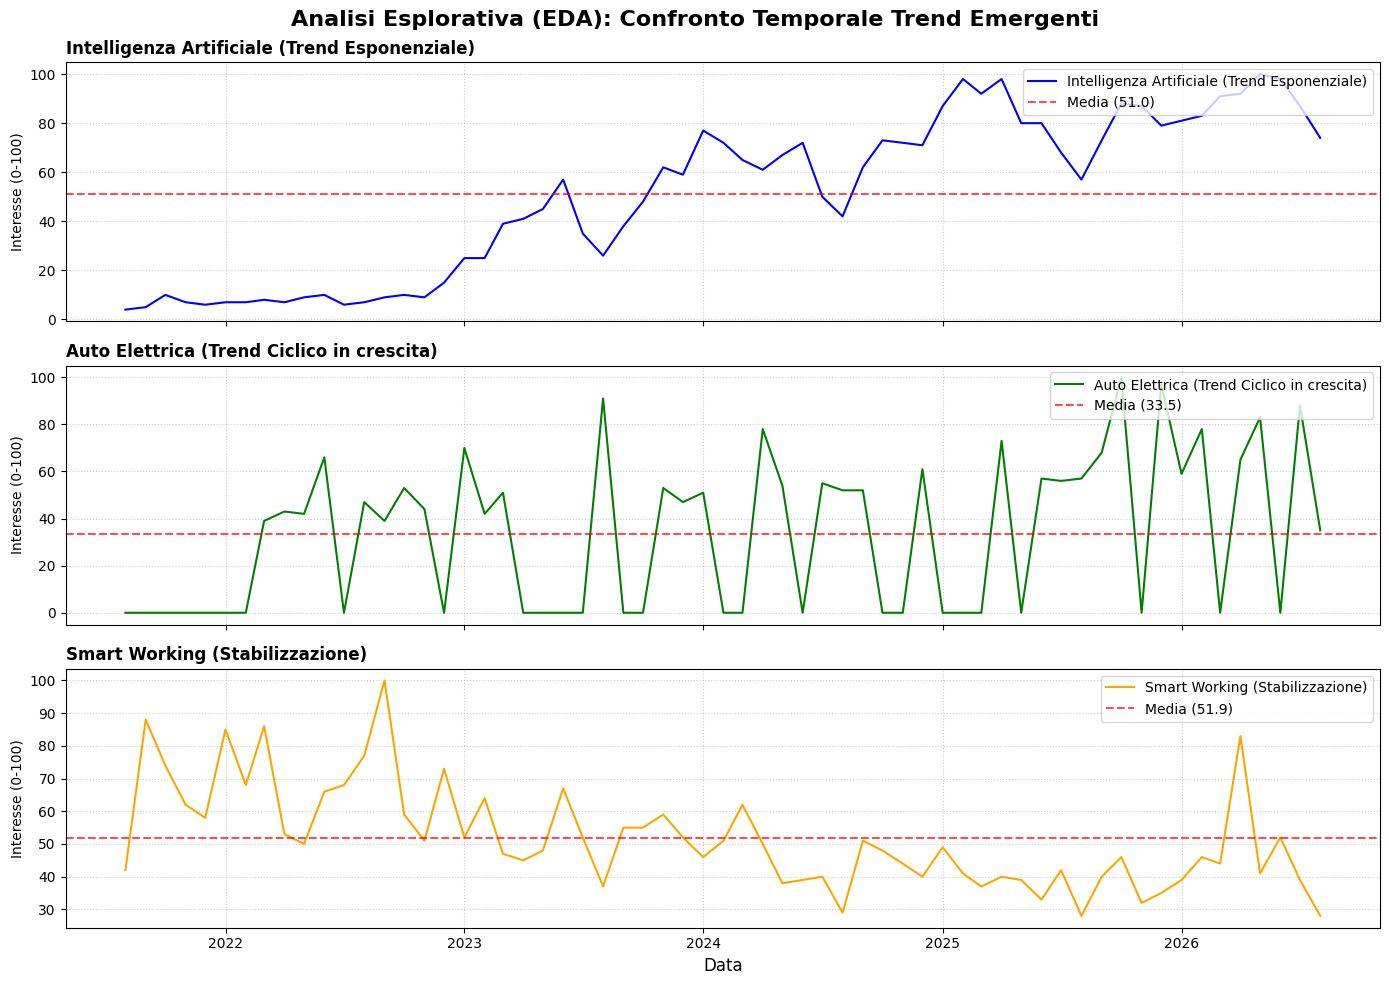

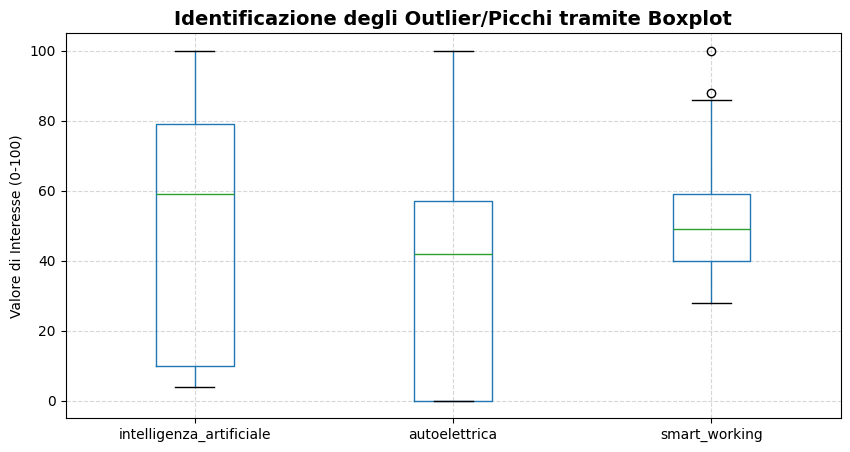

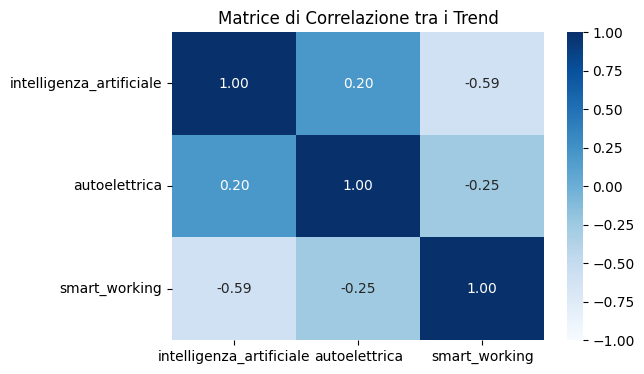

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# statistiche descrittive
print("\n--- STATISTICHE DESCRITTIVE ---")
print(df_laura.describe())

# grafici delle serie temporali
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True) # crea la griglia di sottografici

eventi = [
    ('intelligenza_artificiale', 'blue', 'Intelligenza Artificiale (Trend Esponenziale)'),
    ('autoelettrica', 'green', 'Auto Elettrica (Trend Ciclico in crescita)'),
    ('smart_working', 'orange', 'Smart Working (Stabilizzazione)')
]

# viene accoppiato ogni sotto-grafico con i dettagli di ciascun evento
for ax, (colonna, colore, titolo) in zip(axes, eventi):
    # linea principale della serie temporale
    ax.plot(df_laura.index, df_laura[colonna], label=titolo, color=colore, linewidth=1.5)

    # linea della media
    media = df_laura[colonna].mean()
    ax.axhline(media, color='red', linestyle='--', alpha=0.7, label=f'Media ({media:.1f})')

    ax.set_title(titolo, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Interesse (0-100)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

# asse X comune
axes[-1].set_xlabel('Data', fontsize=12)
fig.suptitle('Analisi Esplorativa (EDA): Confronto Temporale Trend Emergenti', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


# identificazione outlier con boxplot
plt.figure(figsize=(10, 5))
df_laura.boxplot(column=['intelligenza_artificiale', 'autoelettrica', 'smart_working'])

plt.title('Identificazione degli Outlier/Picchi tramite Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Valore di Interesse (0-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# matrice di correlazione
plt.figure(figsize=(6, 4))
sns.heatmap(df_laura.corr(), annot=True, cmap='Blues', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matrice di Correlazione tra i Trend')
plt.show()

5. **Outlier detection / preprocessing** trasformazione dei dati grezzi in un formato idoneo per l'addestramento dei modelli predittivi

In [ ]:
import pandas as pd

df_prep = df_laura.copy()

df_prep['Mese'] = df_prep.index.month
df_prep['Settimana'] = df_prep.index.isocalendar().week.astype(int)

for col in ['intelligenza_artificiale', 'autoelettrica', 'smart_working']:
    df_prep[f'{col}_lag1'] = df_prep[col].shift(1) #feature di memoria storica
df_prep.dropna(inplace=True)

#split Temporale
data_cerniera = '2025-06-01'

train = df_prep[df_prep.index < pd.to_datetime(data_cerniera)]
test = df_prep[df_prep.index >= pd.to_datetime(data_cerniera)]

print(f"Dataset di Training: {train.shape[0]} righe")
print(f"Dataset di Testing: {test.shape[0]} righe")

Dataset di Training: 45 righe
Dataset di Testing: 15 righe


6. **Scelta e implementazione modelli:** In questa fase verranno addestrati due modelli differenti:

**Regressione lineare:** È il modello supervisionato di riferimento semplice e interpretabile. Utilizziamo una combinazione lineare delle feature per essere in grado di stimare il valore dei target. Serve da baseline per valutare se algoritmi più complessi portano un reale vantaggio sulle serie temporali.

**Extra Trees Regressor:** È il modello di Machine Learning avanzato (Extremely Randomized Trees) scelto per questa analisi. Si tratta di un algoritmo "ensemble" ad alberi decisionali che introduce un'estrema casualità nei punti di taglio, riducendo drasticamente la varianza e risultando formidabile per catturare trend di crescita o decrescita. Usa le feature preparate prima (Mese, Settimana e Lag) per mappare l'andamento non lineare.

6.1. **Impostazione dell'addestramento multi-casistica:** Utilizzando il dataset unificato e preelaborato, si definisce la struttura di codice per applicare l'addestramento dei modelli su ciascuna delle tre casistiche. Per ogni evento, le feature definite in precedenza vengono passate alle matrici di Training e Test rispettando l'ordine cronologico.

In [ ]:
dataset_casistiche = {}

for item in eventi:
    target = item[0] if isinstance(item, tuple) else item
    features = ['Mese', 'Settimana', f'{target}_lag1']

    dataset_casistiche[target] = {
        'X_train': train[features],
        'y_train': train[target],
        'X_test': test[features],
        'y_test': test[target],
        'features': features
    }

print("--- Impostazione Dataset completata per le 3 casistiche ---")
for item in eventi:
    target = item[0] if isinstance(item, tuple) else item
    print(f"Casistica '{target}': Train = {dataset_casistiche[target]['X_train'].shape[0]} righe, Test = {dataset_casistiche[target]['X_test'].shape[0]} righe")

--- Impostazione Dataset completata per le 3 casistiche ---
Casistica 'intelligenza_artificiale': Train = 45 righe, Test = 15 righe
Casistica 'autoelettrica': Train = 45 righe, Test = 15 righe
Casistica 'smart_working': Train = 45 righe, Test = 15 righe


6.2. **Implementazione del modello di Baseline: Regressione Lineare** Come primo approccio si implementa la Regressione Lineare, che funge da modello di riferimento. Poiché la regressione lineare può estrapolare valori negativi, si applica una correzione tramite la funzione np.clip per azzerare le stime inferiori allo zero.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eventi_puliti = [item[0] if isinstance(item, tuple) else item for item in eventi]

# definizione dizionari
modelli_lr = {}
previsioni_lr = {}
coefficienti_lr = {}

print("--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---\n")

for item in eventi:
    target = item[0] if isinstance(item, tuple) else item

    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # addestramento del modello
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)

    # predizione dei valori negativi
    pred_lr = model_lr.predict(X_test)
    pred_lr = np.clip(pred_lr, 0, None)

    # calcolo delle metriche
    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # salvataggio
    modelli_lr[target] = model_lr
    previsioni_lr[target] = pred_lr
    coefficienti_lr[target] = model_lr.coef_

    # stampaq dei risultati per ciascun evento
    print(f"Casistica: {target.upper()}")
    print(f"  - Intercetta (Bias): {model_lr.intercept_:.2f}")
    print(f"  - Coefficienti (Pesi feature):")
    for feat, coef in zip(X_train.columns, model_lr.coef_):
        print(f"      {feat}: {coef:.2f}")
    print(f"  - Performance sul Test Set -> MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")
    print("-" * 50)

--- RISULTATI MODELLO BASELINE: REGRESSIONE LINEARE ---

Casistica: INTELLIGENZA_ARTIFICIALE
  - Intercetta (Bias): 5.29
  - Coefficienti (Pesi feature):
      Mese: -0.35
      Settimana: 0.02
      intelligenza_artificiale_lag1: 0.95
  - Performance sul Test Set -> MAE: 6.88 | RMSE: 8.80 | R²: 0.3631
--------------------------------------------------
Casistica: AUTOELETTRICA
  - Intercetta (Bias): 25.57
  - Coefficienti (Pesi feature):
      Mese: -0.77
      Settimana: 0.21
      autoelettrica_lag1: 0.02
  - Performance sul Test Set -> MAE: 40.33 | RMSE: 44.08 | R²: -0.8284
--------------------------------------------------
Casistica: SMART_WORKING
  - Intercetta (Bias): 28.56
  - Coefficienti (Pesi feature):
      Mese: -0.49
      Settimana: 0.23
      smart_working_lag1: 0.43
  - Performance sul Test Set -> MAE: 12.68 | RMSE: 16.00 | R²: -0.5607
--------------------------------------------------


6.3 **Modello Avanzato: Extra Trees Regressor:** L'Extra Trees Regressor è stato sottoposto a una procedura di Hyperparameter Tuning tramite GridSearchCV.
Per ciascuna delle tre casistiche, viene eseguita una ricerca su una griglia di iperparametri per trovare la combinazione ottimale in grado di minimizzare l'errore predittivo: n_estimators  e max_depth . Attraverso una validazione incrociata l'algoritmo individua la configurazione migliore per ogni specifico evento, garantendo l'assetto ottimale per ogni casistica.

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

eventi_puliti = [item[0] if isinstance(item, tuple) else item for item in eventi]

# definizione della griglia con parametri da esplorare
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

# dizionari per memorizzare i modelli ottimizzati
modelli_et_ottimizzati = {}
previsioni_et = {}
parametri_ottimali = {}
metriche_et = {}

print("--- OTTIMIZZAZIONE E ADDESTRAMENTO EXTRA TREES ---\n")

for target in eventi_puliti:
    X_train = dataset_casistiche[target]['X_train']
    y_train = dataset_casistiche[target]['y_train']
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # inizializzazione dell'Extra Trees
    et_base = ExtraTreesRegressor(random_state=42)

    # configurazione di GridSearchCV
    grid_search = GridSearchCV(
        estimator=et_base,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=1
    )

    # ottimizzazione sul Training Set
    grid_search.fit(X_train, y_train)

    # previsioni sul TestSet
    best_model = grid_search.best_estimator_ # istanza dell'Extra Trees come modello migliore

    pred_et = best_model.predict(X_test)

    # calcolo delle metriche di performance per l'Extra Trees
    mae_et = mean_absolute_error(y_test, pred_et)
    rmse_et = np.sqrt(mean_squared_error(y_test, pred_et))
    r2_et = r2_score(y_test, pred_et)


    modelli_et_ottimizzati[target] = best_model
    parametri_ottimali[target] = grid_search.best_params_
    previsioni_et[target] = pred_et

    # stampa a video dei risultati dettagliati per ciascun evento
    print(f"Casistica: {target.upper()}")
    print(f"  - Migliori iperparametri trovati: {grid_search.best_params_}")
    print(f"  - Performance sul Test Set -> MAE: {mae_et:.2f} | RMSE: {rmse_et:.2f} | R²: {r2_et:.4f}")
    print("-" * 65)

--- OTTIMIZZAZIONE E ADDESTRAMENTO EXTRA TREES ---

Casistica: INTELLIGENZA_ARTIFICIALE
  - Migliori iperparametri trovati: {'max_depth': 10, 'n_estimators': 50}
  - Performance sul Test Set -> MAE: 8.21 | RMSE: 10.50 | R²: 0.0935
-----------------------------------------------------------------
Casistica: AUTOELETTRICA
  - Migliori iperparametri trovati: {'max_depth': 10, 'n_estimators': 50}
  - Performance sul Test Set -> MAE: 40.47 | RMSE: 47.87 | R²: -1.1562
-----------------------------------------------------------------
Casistica: SMART_WORKING
  - Migliori iperparametri trovati: {'max_depth': 10, 'n_estimators': 100}
  - Performance sul Test Set -> MAE: 10.41 | RMSE: 13.38 | R²: -0.0916
-----------------------------------------------------------------


6.4. **Estrazione e organizzazione delle previsioni:** Mantenendo l'indice temporale originale dell'ultimo anno di osservazioni, le stime prodotte dalla Regressione Lineare e dall'Extra Trees Regressor vengono affiancate ai valori reali di ricerca. Questa fase conclude l'implementazione tecnica dei modelli, organizzando gli output predittivi in un formato pronto per la successiva fase di valutazione quantitativa e calcolo delle metriche di performance.

In [ ]:
import pandas as pd

# raccolta dei risultati
risultati_previsioni = {}

eventi_puliti = list(dataset_casistiche.keys())

for target in eventi_puliti:
    # creazione del DataFrame di confronto
    df_pred = pd.DataFrame({
        'Valore_Reale': dataset_casistiche[target]['y_test'],
        'Pred_Reg_Lineare': previsioni_lr[target],
        'Pred_Extra_Trees': previsioni_et[target],
    }, index=dataset_casistiche[target]['X_test'].index)


    risultati_previsioni[target] = df_pred

# visualizzazione delle prime 5 osservazioni per ogni evento
print("--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---")
for target in eventi_puliti:
    print(f"\n[Casistica: {target.upper()}] (Prime 5 osservazioni)")
    print(risultati_previsioni[target].head(5))

--- ANTEPRIMA DELLE PREVISIONI SUL TEST SET ---

[Casistica: INTELLIGENZA_ARTIFICIALE] (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Extra_Trees
Data                                                        
2025-06-01            80         79.774515            73.860
2025-07-01            68         79.541631            65.000
2025-08-01            57         67.876199            57.325
2025-09-01            73         57.184707            52.880
2025-10-01            88         72.141187            71.890

[Casistica: AUTOELETTRICA] (Prime 5 osservazioni)
            Valore_Reale  Pred_Reg_Lineare  Pred_Extra_Trees
Data                                                        
2025-06-01            57         25.655951             0.000
2025-07-01            56         26.995636            20.988
2025-08-01            57         27.063078            48.588
2025-09-01            68         27.380088            42.268
2025-10-01           100         27.666673    

7. **Valutazione e controllo dei risultati:** valutazione dell'accuratezza dei due modelli e scelta del modello migliore

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# funzione per calcolare le metriche
def calcola_metriche(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

risultati_metriche = {}

for target in dataset_casistiche.keys():
    # recupero dei dati
    X_test = dataset_casistiche[target]['X_test']
    y_test = dataset_casistiche[target]['y_test']

    # regressione lineare
    pred_lr = modelli_lr[target].predict(X_test)
    pred_lr = np.clip(pred_lr, 0, None)
    met_lr = calcola_metriche(y_test, pred_lr)

    # Extra Trees Regressor
    pred_et = modelli_et_ottimizzati[target].predict(X_test)
    pred_et = np.clip(pred_et, 0, None)
    met_et = calcola_metriche(y_test, pred_et)


    risultati_metriche[f'{target} -LinReg'] = met_lr
    risultati_metriche[f'{target} -ExtraTrees'] = met_et


df_risultati_finali = pd.DataFrame.from_dict(risultati_metriche, orient='index')

print("-- TABELLA COMPARATIVA PERFORMANCE MODELLI --\n")
print(df_risultati_finali)

-- TABELLA COMPARATIVA PERFORMANCE MODELLI --

                                            MAE       RMSE        R2
intelligenza_artificiale -LinReg       6.878653   8.799446  0.363145
intelligenza_artificiale -ExtraTrees   8.209000  10.498276  0.093504
autoelettrica -LinReg                 40.330244  44.076795 -0.828380
autoelettrica -ExtraTrees             40.469400  47.865460 -1.156210
smart_working -LinReg                 12.680149  16.004128 -0.560682
smart_working -ExtraTrees             10.410111  13.384609 -0.091595


8. **Conclusioni finali:** L'Extra Trees Regressor risulta migliore rispetto alla Regressione Lineare e lo si può osservare attraverso le metriche studiate che analizzano l'errore tra il valore reale e quello previsto.

**MAE** misura l'errore medio in valore assoluto, più è basso più il valore è preciso.

**RMSE** misura dando peso agli errori più grandi, più è basso meglio è.

**R2** indica quanta variabilità dei dati il modello riesce a spiegare, più il valore è vicino a 1, più il modello è eccellente.

Quindi osservando i valori, l'Extra Trees Regressor risulta nettamente migliore. La Regressione Lineare fa fatica perché è vincolata da un'assunzione di linearità troppo rigida, quindi fallisce nel prevedere in modo accurato le forti crescite esponenziali o i cambi strutturali. Al contrario, l'Extra Trees ha una natura non lineare basata su alberi decisionali estremamente randomizzati e quindi riesce a catturare e prevedere con molta più precisione l'andamento reale dei trend.